In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import sklearn 

print("numpy:",np.__version__)
print("pandas:",pd.__version__)
print("sklearn:",sklearn.__version__)
print("wfdb:",wfdb.__version__)
print("all the libraries loaded succesfully")

numpy: 2.4.3
pandas: 2.2.2
sklearn: 1.8.0
wfdb: 4.3.1
all the libraries loaded succesfully


In [2]:
import wfdb 
wfdb.dl_database('mitdb', dl_dir='data/mitdb', records=['100'])

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files


In [3]:
import os 
print(os.listdir('data/mitdb'))

['213.dat', '208.hea', '200.dat', '106.dat', '100.dat', '101.dat', '208.atr', '101.hea', '100.hea', '213.atr', '106.hea', '200.atr', '200.hea', '106.atr', '208.dat', '213.hea', '100.atr', '101.atr']


In [4]:
record=wfdb.rdrecord('data/mitdb/100') # read the ECG records

annotation=wfdb.rdann('data/mitdb/100','atr') # read the annotations 

print("Signal shape:",record.p_signal.shape)
print("Signal frequency:",record.fs,"Hz")
print("Signal names:", record.sig_name)
print("Number of annotation:",len(annotation.sample))
print("First 20 annotations:",annotation.symbol[0:20])


Signal shape: (650000, 2)
Signal frequency: 360 Hz
Signal names: ['MLII', 'V5']
Number of annotation: 2274
First 20 annotations: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


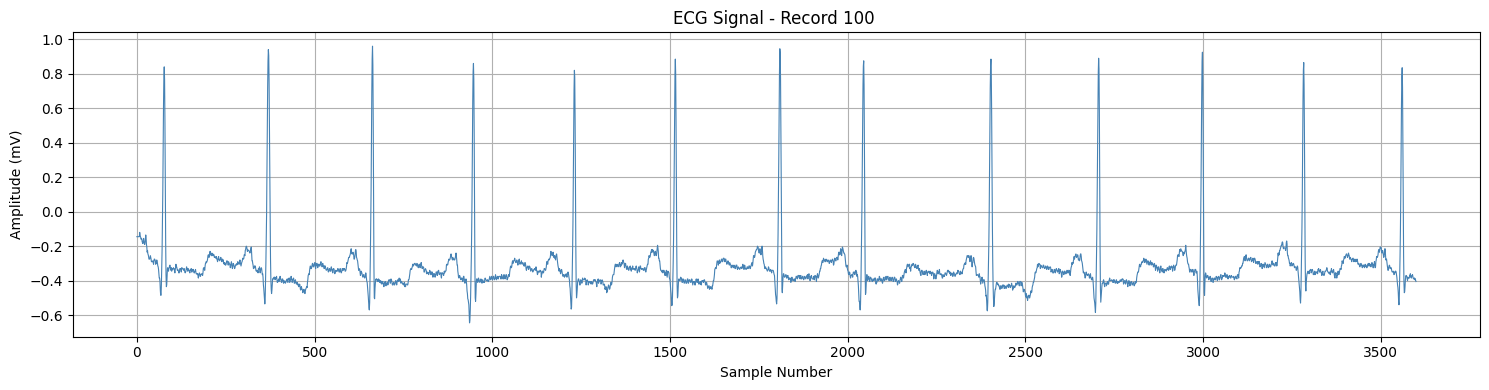

In [5]:
fs=record.fs # 360 hz
duration=10 # seconds
samples=fs*duration # 3600 samples

plt.figure(figsize=(15,4))
plt.plot(record.p_signal[:samples, 0], color='steelblue', linewidth=0.8)
plt.title('ECG Signal - Record 100 ')
plt.xlabel('Sample Number')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.tight_layout()
plt.show()


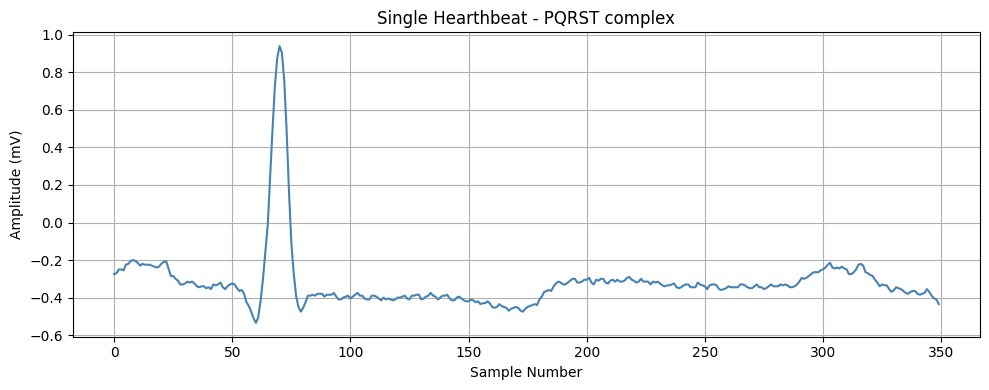

In [6]:
# zoom into a single hearth beat
plt.figure(figsize=(10,4))
plt.plot(record.p_signal[300:650,0], color='steelblue', linewidth=1.5)
plt.title('Single Hearthbeat - PQRST complex')
plt.xlabel('Sample Number')
plt.ylabel('Amplitude (mV)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [7]:
import numpy as np 

# Our window parameters 
fs=360 # sampling frequency
before=90 # sampling before R peak
after=126 # sampling after R peak
window_size=before+after # 216 total 

# Signal and annotations 
signal=record.p_signal[:,0] # ML 2 lead only
r_peaks=annotation.sample # r peaks location
symbols=annotation.symbol # beat labels 

beats=[]
labels=[]

for i, peak in enumerate(r_peaks):
    if peak - before < 0 or peak + after > len(signal):
        continue 

    window=signal[peak-before : peak+after]

    beats.append(window)
    labels.append(symbols[i])

beats=np.array(beats)
labels=np.array(labels)

print("Total beats extracted:", len(beats))
print("Shape of beats array:", beats.shape)
print("Unique labels :", np.unique(labels))




Total beats extracted: 2271
Shape of beats array: (2271, 216)
Unique labels : ['A' 'N' 'V']


In [8]:
print("First 10 labels:", labels[:10])
print("Unique labels:", np.unique(labels))


First 10 labels: ['N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N' 'N']
Unique labels: ['A' 'N' 'V']


In [9]:
unique,counts=np.unique(labels, return_counts=True)
for label,count in zip(unique,counts):
    print(f"{label}:{count} beats ({100*count/len(labels):.1f}%)")

A:33 beats (1.5%)
N:2237 beats (98.5%)
V:1 beats (0.0%)


In [10]:
records_to_load=['100', '101', '106', '200', '208', '213']
wfdb.dl_database('mitdb', dl_dir='data/mitdb', records=records_to_load)
print("Download records:", records_to_load)

Generating record list for: 100
Generating record list for: 101
Generating record list for: 106
Generating record list for: 200
Generating record list for: 208
Generating record list for: 213
Generating list of all files for: 100
Generating list of all files for: 101
Generating list of all files for: 106
Generating list of all files for: 200
Generating list of all files for: 208
Generating list of all files for: 213
Finished downloading files
Download records: ['100', '101', '106', '200', '208', '213']


In [11]:
import wfdb
import numpy as np
def extract_beats(record_path, before=90, after=126):
    
    record=wfdb.rdrecord(record_path)
    annotation=wfdb.rdann(record_path,'atr')
    
    # Signal and annotations 
    signal=record.p_signal[:,0] # ML 2 lead only
    r_peaks=annotation.sample # r peaks location
    symbols=annotation.symbol # beat labels 

    beats=[]
    labels=[]

    for i, peak in enumerate(r_peaks):
        if peak - before < 0 or peak + after > len(signal):
            continue 

        window=signal[peak-before : peak+after]

        beats.append(window)
        labels.append(symbols[i])

    beats=np.array(beats)
    labels=np.array(labels)

    
    return beats, labels 

    

    
    
    
    

In [12]:
record_ids=['100', '101', '106', '200', '208', '213']
all_beats=[]
all_labels=[]
for rec_id in record_ids:
    record_path=f'data/mitdb/{rec_id}'
    beats,labels=extract_beats(record_path)
    all_beats.append(beats)
    all_labels.append(labels)
    print(f"Record : {rec_id} : {len(beats)} beats extracted")
    
all_beats=np.concatenate(all_beats,axis=0)
all_labels=np.concatenate(all_labels,axis=0)

print("\nTotal beats:",len(all_beats))
print("Shape:", all_beats.shape)

unique, counts = np.unique(all_labels, return_counts=True)
for label, count in zip(unique, counts):
    print(f"{label}: {count} beats ({100*count/len(all_labels):.1f}%)")
    
    
    
    


Record : 100 : 2271 beats extracted
Record : 101 : 1872 beats extracted
Record : 106 : 2097 beats extracted
Record : 200 : 2790 beats extracted
Record : 208 : 3037 beats extracted
Record : 213 : 3292 beats extracted

Total beats: 15359
Shape: (15359, 216)
+: 282 beats (1.8%)
A: 91 beats (0.6%)
F: 736 beats (4.8%)
N: 11570 beats (75.3%)
Q: 4 beats (0.0%)
S: 2 beats (0.0%)
V: 2559 beats (16.7%)
a: 3 beats (0.0%)
|: 12 beats (0.1%)
~: 100 beats (0.7%)


In [13]:
valid_labels=['N','V','A','F'] # Keep only these labels 
mask=np.isin(all_labels, valid_labels)

filtered_beats=all_beats[mask]
filtered_labels=all_labels[mask]

# binary conversion - normal=0 , abnormal=1

binary_labels=np.where(filtered_labels =='N',0,1)

print("Filtered beats shape:", filtered_beats.shape)
print("Normal beats:", np.sum(binary_labels==0))
print("Abnormal beats:", np.sum(binary_labels==1))
print("Imbalance ratio :", round(np.sum(binary_labels==0)/np.sum(binary_labels==1),1),":1")

Filtered beats shape: (14956, 216)
Normal beats: 11570
Abnormal beats: 3386
Imbalance ratio : 3.4 :1


In [14]:
# Downsampling required for better --> training

normal_idx=np.where(binary_labels==0)[0]
abnormal_idx=np.where(binary_labels==1)[0]

np.random.seed(42)
normal_idx_downsampled=np.random.choice(
    normal_idx,
    size=len(abnormal_idx),
    replace=False)

balanced_idx=np.concatenate([normal_idx_downsampled, abnormal_idx])
np.random.shuffle(balanced_idx)

balanced_beats=filtered_beats[balanced_idx]
balanced_labels=binary_labels[balanced_idx]

print("Balanced beats shape:", balanced_beats.shape)
print("Normal beats:", np.sum(balanced_labels==0))
print("Abnormal beats:", np.sum(balanced_labels==1))







Balanced beats shape: (6772, 216)
Normal beats: 3386
Abnormal beats: 3386


In [15]:
print("\nDataset Summary:")
print(f"Total beats: {len(balanced_beats)}")
print(f"Beat window size: {balanced_beats.shape[1]} samples")
print(f"Normal beats: {np.sum(balanced_labels==0)} ")
print(f"Abnormal beats: {np.sum(balanced_labels==1)} ")
print(f"Class balance: {np.sum(balanced_labels==0)/np.sum(balanced_labels==1):.1f}:1")
print(f"Data is ready for training: {balanced_beats.shape}")



Dataset Summary:
Total beats: 6772
Beat window size: 216 samples
Normal beats: 3386 
Abnormal beats: 3386 
Class balance: 1.0:1
Data is ready for training: (6772, 216)


In [16]:
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt 

X_train, X_test, Y_train, Y_test = train_test_split(
    balanced_beats,
    balanced_labels,
    test_size=0.2,
    random_state=42,
    stratify=balanced_labels
)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print(f"Normal beats: {np.sum(Y_train==0)}")
print(f"Abnormal beats: {np.sum(Y_train==1)}")



    

Training set shape: (5417, 216)
Testing set shape: (1355, 216)
Normal beats: 2708
Abnormal beats: 2709


In [17]:
rf_model=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
print("Training model..")
rf_model.fit(X_train, Y_train)
print("Training completed")
y_pred=rf_model.predict(X_test)
print("Prediction made.")


Training model..
Training completed
Prediction made.


In [18]:
from sklearn.metrics import classification_report, confusion_matrix
print("\nModel Performance")
print(classification_report(Y_test, y_pred,
                            target_names=['Normal','Abnormal']))
      
      


Model Performance
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98       678
    Abnormal       0.99      0.96      0.98       677

    accuracy                           0.98      1355
   macro avg       0.98      0.98      0.98      1355
weighted avg       0.98      0.98      0.98      1355



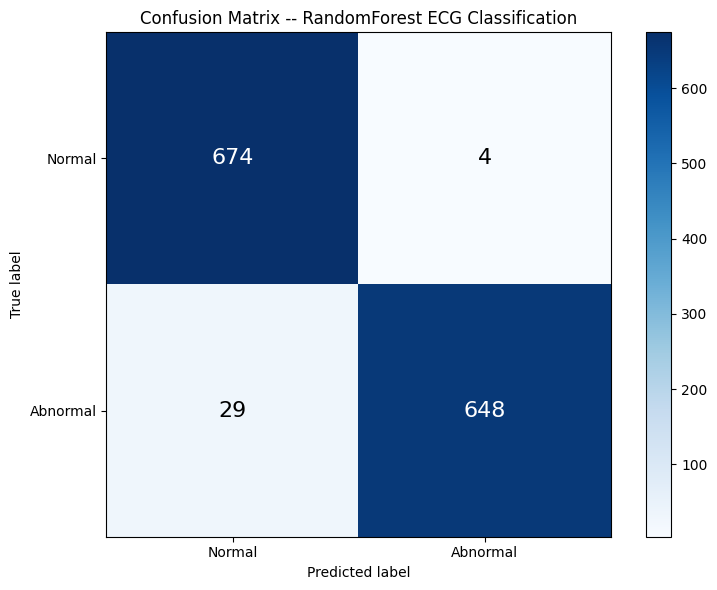


Confusion Matrix:
True Normals(Correctly identified):674
False Abnormal: 4
False normals: 29
True Abnormals: 648


In [19]:
cm=confusion_matrix(Y_test, y_pred)
                    
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix -- RandomForest ECG Classification')
plt.colorbar()
plt.xticks([0,1],['Normal','Abnormal'])
plt.yticks([0,1],['Normal','Abnormal'])

for i in range(2):
    for j in range(2):
        plt.text(j,i, cm[i,j],
            ha='center', va='center',
            fontsize=16, color='white' if cm[i,j] > cm.max()/2 else 'black')
        
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(f"True Normals(Correctly identified):{cm[0,0]}")
print(f"False Abnormal: {cm[0,1]}")
print(f"False normals: {cm[1,0]}")
print(f"True Abnormals: {cm[1,1]}")


        


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("PyTorch version:", torch.__version__)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/denizhan/ecg_classifier/ecg_env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/denizhan/ecg_classifier/ecg_env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/denizhan/ecg_classifier/ecg_env/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in st

PyTorch version: 2.2.2


In [21]:
class ECGClassifier(nn.Module):
    def __init__(self):
        super(ECGClassifier, self).__init__()

        self.conv1=nn.Conv1d(1, 32, kernel_size=7, padding=3)
        self.conv2=nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.pool=nn.MaxPool1d(2)
        self.relu=nn.ReLU()
        self.dropout=nn.Dropout(0.5)
        self.fc1=nn.Linear(64*54, 128)
        self.fc2=nn.Linear(128, 2)

    def forward(self, x):
        x=self.relu(self.conv1(x))
        x=self.pool(x)
        x=self.relu(self.conv2(x))
        x=self.pool(x)
        x=x.view(x.size(0),-1)
        x=self.dropout(self.relu(self.fc1(x)))
        x=self.fc2(x)
    
        return x
    
model = ECGClassifier()
print(model)

    
    
        
        
        
    

ECGClassifier(
  (conv1): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=3456, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


In [22]:
# Converting numpy arrays to PyTorch tensors
X_train_t=torch.FloatTensor(X_train).unsqueeze(1)
X_test_t=torch.FloatTensor(X_test).unsqueeze(1)
Y_train_t=torch.LongTensor(Y_train)
Y_test_t=torch.LongTensor(Y_test)

# Create dataset and loaders
train_dataset = TensorDataset(X_train_t, Y_train_t)
test_dataset = TensorDataset(X_test_t, Y_test_t)

train_loader =  DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  =  DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Input shape:", X_train_t.shape)
print("Labels shape:", Y_train_t.shape)




Input shape: torch.Size([5417, 1, 216])
Labels shape: torch.Size([5417])


In [23]:
# Loss function and optimizer
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)
# training setup 
epochs=20
train_losses=[]

print("Starts training...")

for epoch in range(epochs):
    
    model.train()
    running_loss=0.0

    for beats, labels in train_loader:
        
        optimizer.zero_grad()
        outputs=model(beats)
        loss=criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_loss=running_loss/len(train_loader)
    train_losses.append(avg_loss)

    if (epoch+1)%5 == 0:
        print(f"Epoch: {epoch+1}/{epochs} - loss: {avg_loss:.4f}")

print("Training is over.")
    
    
        
        
    
    




Starts training...
Epoch: 5/20 - loss: 0.0969
Epoch: 10/20 - loss: 0.0811
Epoch: 15/20 - loss: 0.0632
Epoch: 20/20 - loss: 0.0572
Training is over.


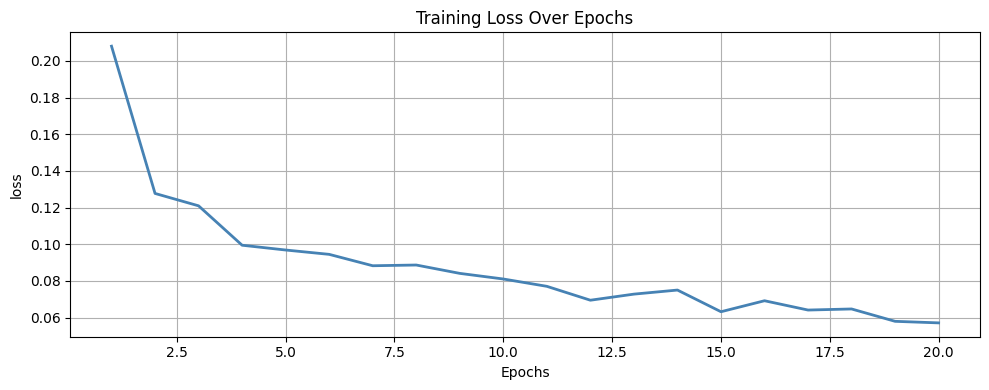

In [24]:
plt.figure(figsize=(10,4))
plt.plot(range(1,epochs+1),train_losses, color='steelblue', linewidth=2)
plt.title('Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
model.eval()
correct=0
total=0
all_pred=[]
all_true=[]

with torch.no_grad():
    for beats, labels in test_loader:
        outputs=model(beats)
        _, predicted=torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted==labels).sum().item()
        all_pred.extend(predicted.tolist())
        all_true.extend(labels.tolist())
        
print(f"Neural Network Accuracy : {100*correct/total:.2f}%")

print("\n -- Classification Report --")
print(classification_report(all_true, all_pred,
                             target_names=['Normal','Abnormal']))





Neural Network Accuracy : 97.71%

 -- Classification Report --
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98       678
    Abnormal       0.99      0.96      0.98       677

    accuracy                           0.98      1355
   macro avg       0.98      0.98      0.98      1355
weighted avg       0.98      0.98      0.98      1355

